### 🧠 Autonomous RAG Agent Architecture

### Pipeline Overview

1. User Query  
2. Query Planner (Decompose)  
3. Retriever (RAG)  
4. Reasoning Agent (ReAct + CoT)  
5. Answer Generator  
6. Self-Reflection (Critique)  
7. If bad → Improve Query → Repeat  
8. Else → Final Answer

| Concept                    | Role in System                               |
| -------------------------- | -------------------------------------------- |
| **Query Planning**         | Break complex question into sub-questions    |
| **ReAct**                  | Tool usage + reasoning (search + think loop) |
| **CoT (Chain of Thought)** | Step-by-step reasoning inside LLM            |
| **Iterative Strategy**     | Retry with improved query                    |
| **Self Reflection**        | Critic agent validates answer quality        |


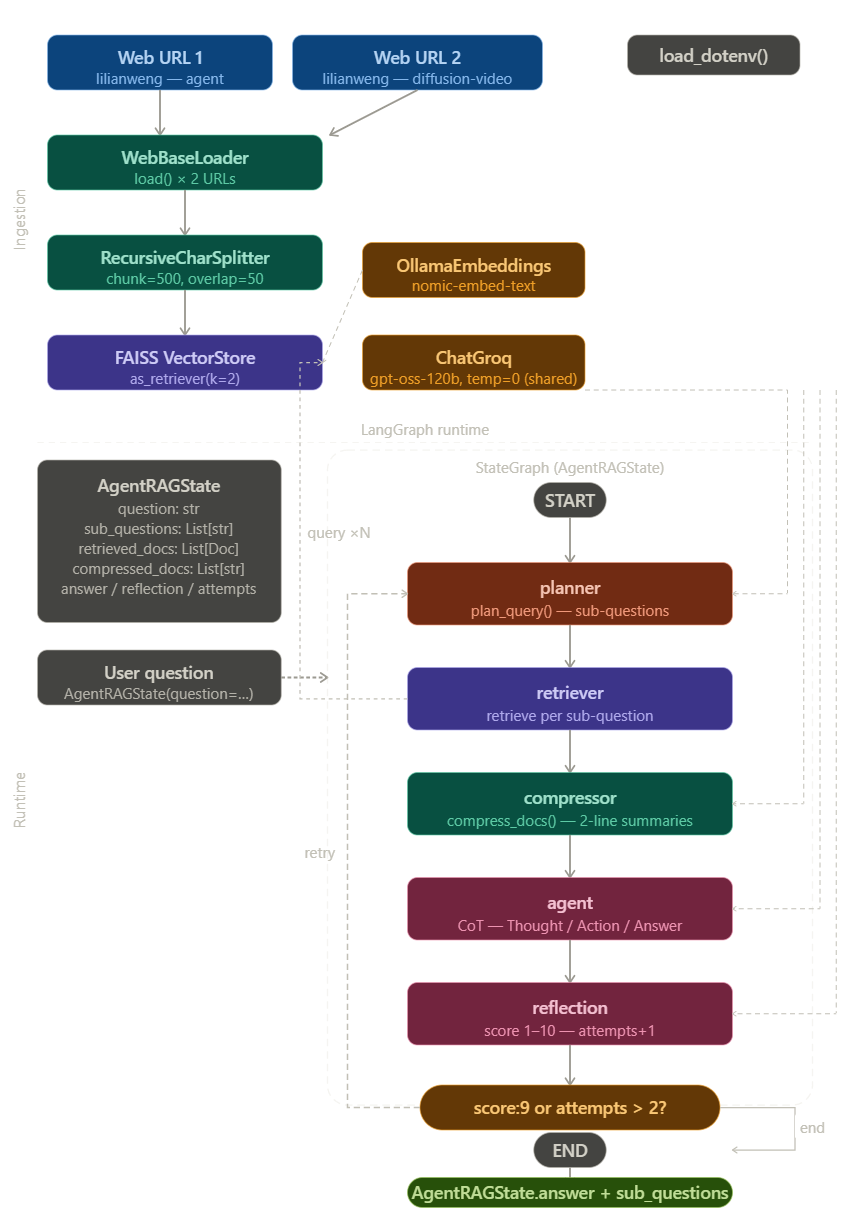

In [16]:
# ------------------------------------------------------------
# 1. Load Text File, Embeddings, Vector Store and LLM 
# ------------------------------------------------------------

from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_ollama.embeddings import OllamaEmbeddings
from langchain_groq import ChatGroq

import os
from dotenv import load_dotenv

load_dotenv()
os.environ['GROQ_API_KEY'] = os.getenv('groq_api_key')

urls = [
    'https://lilianweng.github.io/posts/2023-06-23-agent/',
    'https://lilianweng.github.io/posts/2024-04-12-diffusion-video/'
]

docs = []
for url in urls:
    docs.extend(WebBaseLoader(url).load())
    
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = text_splitter.split_documents(docs)

embedding = OllamaEmbeddings(model='nomic-embed-text')

vector_db = FAISS.from_documents(chunks, embedding)
retriever = vector_db.as_retriever(search_kwargs={"k": 2})

llm = ChatGroq(model='openai/gpt-oss-120b', max_tokens=1000, temperature=0)

In [23]:
# ------------------------------------------------------------
# 2. LangGraph State Definition 
# ------------------------------------------------------------

from typing import List
from pydantic import BaseModel
from langchain_classic.schema import Document

class AgentRAGState(BaseModel):
    question: str
    sub_questions: List[str] = []
    retrieved_docs: List[Document] = []
    compressed_docs: List[str] = []
    answer: str = ''
    reflection: str = ''
    attempts: int = 0

In [24]:
# ------------------------------------------------------------
# 3. Query Planner and Decomposition 
# ------------------------------------------------------------

# a) Query Planning + Decomposition
def plan_query(state: AgentRAGState) -> AgentRAGState:
    prompt = f"""
        Break the question into smaller sub-question:
        Question: {state.question}
        Sub-Question:
    """
    result = llm.invoke(prompt)
    sub_questions = [question.strip('- ').strip() for question in result.content.strip().split('\n') if question.strip()]
    print('⁉️ Sub questions:\n', sub_questions)
    return state.model_copy(update={'sub_questions': sub_questions})

# b) Retrieve documents for each sub-questions
def retriever_each_sub_questions(state: AgentRAGState) -> AgentRAGState:
    all_docs = []
    for sub in state.sub_questions:
        doc = retriever.invoke(sub)
        all_docs.extend(doc)
    
    print('📚 Retrieval Documents:\n', all_docs)
    return state.model_copy(update={'retrieved_docs': all_docs})

# c) Compressor -  Retriever Document
def compress_docs(state: AgentRAGState) -> AgentRAGState:
    summaries = []
    for doc in state.retrieved_docs:
        summary = llm.invoke(f"Summarize in 2 lines:\n{doc.page_content[:500]}").content
        summaries.extend(summary)
    return state.model_copy(update={'compressed_docs': summaries})

# d) ReAct + CoT Agent
def agent(state: AgentRAGState) -> AgentRAGState:
    context = "\n\n".join(state.compressed_docs[:5])
    prompt = f"""
        You are an AI agent using reasoning and retrieved documents.
        
        Question: {state.question}
        Relevant Information: {context}
        
        Think step by step (Chain of Thought) and then answer.
        
        Format:
        Thought:
        Action:
        Observation:
        Final Answer:
    """
    result = llm.invoke(prompt).content.strip()
    print('🤖 Generated Answer:\n', result)
    return state.model_copy(update={'answer': result})

# e) Self Reflection
def reflection_on_answer(state: AgentRAGState) -> AgentRAGState:
    prompt = f"""
        Evaluate the answer:
        
        Question: {state.question}
        Answer: {state.answer}
        
        Is this correct? If not, explain why.
        Give a score from 1-10.    
    """
    result = llm.invoke(prompt)
    return state.model_copy(update={'reflection': result, 'attempts': state.attempts + 1})

# f) Decision Node (Iteration Control)
def should_continue(state: AgentRAGState) -> AgentRAGState:
    if 'score: 9' in state.reflection.lower() or state.attempts > 2:
        return 'end'
    return 'retry'

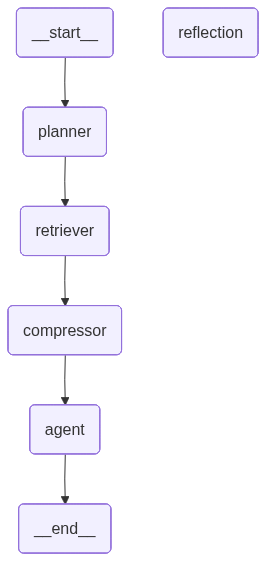

In [25]:
# ------------------------------------------------------------
# 4. LangGraph 
# ------------------------------------------------------------

from langgraph.graph import StateGraph, END
from IPython.display import Image, display

build = StateGraph(AgentRAGState)

build.add_node('planner', plan_query)
build.add_node('retriever', retriever_each_sub_questions)
build.add_node('compressor', compress_docs)
build.add_node('agent', agent)
build.add_node('reflection', reflection_on_answer)

build.set_entry_point('planner')
build.add_edge('planner', 'retriever')
build.add_edge('retriever', 'compressor')
build.add_edge('compressor', 'agent')
build.add_conditional_edges(
    'reflection',
    should_continue,
    {
        'retry': 'planner',
        'end': END
    }
)

graph = build.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [26]:
# ------------------------------------------------------------
# 5. Run the Agent 
# ------------------------------------------------------------

if __name__ == '__main__':
    query = 'Explain how agent loops work and what are the challenges in diffusion video generation?'
    state = AgentRAGState(question=query)
    result = graph.invoke(state)
    
    print('\n 🔎 Sub-Questions:')
    for q in result['sub_questions']:
        print('-', q)
    
    print('\n ✅ Final Answer: \n', result['answer'])

⁉️ Sub questions:
 ['**Breaking the question into smaller, focused sub‑questions**', '', '### Part\u202f1 – Agent Loops', '1. **What is an “agent loop” in the context of autonomous AI systems?**', '2. **What are the core components of an agent loop (e.g., perception, reasoning, action, memory, feedback)?**', '3. **How does the loop acquire input (observations, user prompts, tool outputs) and turn it into internal representations?**', '4. **What role does a language model (or other reasoning engine) play inside the loop?**', '5. **How are actions selected and executed (e.g., calling APIs, manipulating environments, generating text)?**', '6. **How does the loop incorporate the results of its actions back into its state (updating memory, context, or world model)?**', '7. **What mechanisms are used for self‑reflection, error detection, or plan revision within the loop?**', '8. **How is the loop terminated or paused (goal achievement, time‑out, external interrupt)?**', '9. **What are common